<a href="https://colab.research.google.com/github/shawn-maybush/3D-Kinematics-Analytics/blob/main/quaternion_ml_ik_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Inverse Kinematics with Dual Quaternions and Machine Learning



##System Check

In [1]:
from psutil import *
# This code will return the number of CPU
print("Number of CPU: ", cpu_count())
import psutil
split_bar = '='*20
memory_info = psutil.virtual_memory()._asdict()
print(f"{split_bar} Memory Usage {split_bar}")
for k,v in memory_info.items():
  print(k, v)
print(f"{split_bar} CPU Usage {split_bar}")
print(f"CPU percent: {psutil.cpu_percent()}%")

Number of CPU:  8
==================== Memory Usage ====================
total 54754004992
available 53443383296
percent 2.4
used 723443712
free 51029016576
active 774950912
inactive 2577981440
buffers 120348672
cached 2881196032
shared 1552384
slab 185061376
==================== CPU Usage ====================
CPU percent: 19.6%


In [2]:
import os
os.environ["XLA_FLAGS"] = f'--xla_force_host_platform_device_count={cpu_count()}'

##Define Forward Kinematics

In [3]:
import sympy
import numpy as np
from IPython.display import display, Math
import pandas as pd
import ipyparallel as ipp
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import qmc

import itertools

import jax.numpy as jnp
from jax import jit, pmap, vmap
from jax import random, debug
import jax
from jax import config
config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec as P
from functools import partial
from jax.experimental.shard_map import shard_map


from typing import Sequence

In [4]:
jax.devices()

[CpuDevice(id=0),
 CpuDevice(id=1),
 CpuDevice(id=2),
 CpuDevice(id=3),
 CpuDevice(id=4),
 CpuDevice(id=5),
 CpuDevice(id=6),
 CpuDevice(id=7)]

In [5]:
cluster = ipp.Cluster(n=cpu_count())
rc = cluster.start_and_connect_sync()
dv = rc[:]
lv = rc.load_balanced_view()

Starting 8 engines with <class 'ipyparallel.cluster.launcher.LocalEngineSetLauncher'>


  0%|          | 0/8 [00:00<?, ?engine/s]

In [6]:
with rc[:].sync_imports():
  import sympy
  from math import pi, sqrt, degrees, radians
  import numpy
  from IPython.display import display, Math
  import pandas

importing sympy on engine(s)
importing pi,sqrt,degrees,radians from math on engine(s)
importing numpy on engine(s)
importing display,Math from IPython.display on engine(s)
importing pandas on engine(s)


In [7]:
def dualq_piecewise_simplify(dq):

  r = dq[0]
  d = dq[1]
  r_scalar = r.scalar_part()
  r_vector = r.to_Matrix(vector_only=True).T.tolist()

  r_list = [r_scalar] + r_vector[0]

  d_scalar = d.scalar_part()
  d_vector = d.to_Matrix(vector_only=True).T.tolist()
  d_list = [d_scalar] + d_vector[0]

  all = r_list + d_list

  all = lv.map_sync(lambda x: sympy.simplify(x), all)

  real_part = sympy.Quaternion(*all[:4])
  dual_part = sympy.Quaternion(*all[4:])

  result = sympy.Matrix([real_part, dual_part])

  return result

def dualq_piecewise_expand(dq):

  r = dq[0]
  d = dq[1]
  r_scalar = r.scalar_part()
  r_vector = r.to_Matrix(vector_only=True).T.tolist()

  r_list = [r_scalar] + r_vector[0]

  d_scalar = d.scalar_part()
  d_vector = d.to_Matrix(vector_only=True).T.tolist()
  d_list = [d_scalar] + d_vector[0]

  all = r_list + d_list

  all = lv.map_sync(lambda x: sympy.expand(x, basic=True), all)

  real_part = sympy.Quaternion(*all[:4])
  dual_part = sympy.Quaternion(*all[4:])

  result = sympy.Matrix([real_part, dual_part])

  return result

def dualq_piecewise_trigsimp(dq):

  r = dq[0]
  d = dq[1]
  r_scalar = r.scalar_part()
  r_vector = r.to_Matrix(vector_only=True).T.tolist()

  r_list = [r_scalar] + r_vector[0]

  d_scalar = d.scalar_part()
  d_vector = d.to_Matrix(vector_only=True).T.tolist()
  d_list = [d_scalar] + d_vector[0]

  all = r_list + d_list

  all = lv.map_sync(lambda x: sympy.trigsimp(x, basic=True), all)

  real_part = sympy.Quaternion(*all[:4])
  dual_part = sympy.Quaternion(*all[4:])

  result = sympy.Matrix([real_part, dual_part])

  return result

In [8]:
def dualq_mul(args):


    if len(args) < 2:
        raise Exception("Need at least 2 dual quaternions to multiply")

    result = args[0]
    for i in range(1, len(args)):
        print(f"Multiplying {i + 1} of {len(args)}")

        dq_i = args[i]

        r1 = result[0]
        d1 = result[1]

        r2 = dq_i[0]
        d2 = dq_i[1]

        real_part = r1.mul(r2)
        dual_part = (r1.mul(d2)).add(d1.mul(r2))

        result = sympy.Matrix([real_part, dual_part])
        result = dualq_piecewise_expand(result)

    result = dualq_piecewise_trigsimp(result)
    return result

In [9]:
joints = [
    [[0,1,0],[0, 0, 0 ], False, (np.deg2rad(-100), np.deg2rad(30))],
    [[1,0,0],[0, 0, 0 ], False, (np.deg2rad(-40), np.deg2rad(20))],
    [[0,0,1],[0, 0, 0 ], False, (np.deg2rad(-50), np.deg2rad(40))],
    [[0,1,0],[0, 0, -400], False, (np.deg2rad(0), np.deg2rad(150))],
    [[0,1,0],[0, 0, -450 ], False,  (np.deg2rad(-30), np.deg2rad(40))],
    [[0,1,0],[230, 0, 0], True, ()]]

dq_joints = []
symbol_idx = 0
target_symbols = []

for joint in joints:
  if joint[2]:
    r = sympy.Quaternion.from_axis_angle(joint[0], 0)
  else:
    angle = sympy.symbols(f'theta_{symbol_idx}', real=True)
    symbol_idx += 1
    target_symbols.append(angle)
    r = sympy.Quaternion.from_axis_angle(joint[0], angle)

  t = sympy.Quaternion(0, joint[1][0], joint[1][1], joint[1][2])
  d = sympy.Rational(0.5) * t.mul(r)
  Q = sympy.Matrix([r, d])
  Q = dualq_piecewise_simplify(Q)
  dq_joints.append(Q)


In [10]:
foot_pose_dqi = dualq_mul(dq_joints)
foot_position_FK = (2 * foot_pose_dqi[1].mul(foot_pose_dqi[0].conjugate()))
foot_position_FK = foot_position_FK.to_Matrix(vector_only=True)
foot_orientation_FK = foot_pose_dqi[0].to_Matrix(vector_only=False)

Multiplying 2 of 6
Multiplying 3 of 6
Multiplying 4 of 6
Multiplying 5 of 6
Multiplying 6 of 6


In [11]:
foot_position_FK_lambda = sympy.lambdify(target_symbols, foot_position_FK, modules=['numpy'], cse=True, docstring_limit=0)
foot_orientation_FK_lambda = sympy.lambdify(target_symbols, foot_orientation_FK, modules=['numpy'], cse=True, docstring_limit=0)

In [12]:
n = 10000

data = pd.DataFrame()

param_ranges = {}

for i in range(len(target_symbols)):

  param_ranges[target_symbols[i]] = joints[i][3]

sampler = qmc.LatinHypercube(d=len(param_ranges))
samples = sampler.random(n=n)
scaled_samples = np.zeros_like(samples)


for i, (param_name, (lower, upper)) in enumerate(param_ranges.items()):
    scaled_samples[:, i] = qmc.scale(samples[:, i].reshape(-1, 1), lower, upper).flatten()

for i in range(n):

    position_x, position_y, position_z = foot_position_FK_lambda(*scaled_samples[i])
    orientation_w, orientation_x, orientation_y, orientation_z = foot_orientation_FK_lambda(*scaled_samples[i])
    feature_symbols = ['position_x', 'position_y', 'position_z','orientation_w', 'orientation_x', 'orientation_y', 'orientation_z']
    headers = target_symbols + feature_symbols
    row = np.concatenate((scaled_samples[i], position_x, position_y, position_z, orientation_w, orientation_x, orientation_y, orientation_z))
    row = pd.DataFrame([row], columns=headers)

    data = pd.concat([data, row], ignore_index=True)

In [13]:
data

,theta_0,theta_1,theta_2,theta_3,theta_4,position_x,position_y,position_z,orientation_w,orientation_x,orientation_y,orientation_z
0,-0.386704,0.255526,0.605662,2.458482,-0.286136,-205.111980,-167.340722,-399.225144,0.623392,-0.248409,0.713511,0.201438
1,-0.440609,-0.566413,0.014208,1.075054,-0.086888,45.699555,-435.795266,-728.231163,0.923844,-0.215576,0.261505,-0.177916
2,0.399015,0.101853,0.087209,0.339789,-0.124851,-268.685796,95.272179,-828.864225,0.951781,0.054642,0.299384,0.038676
3,0.275790,-0.484732,-0.401294,2.574217,-0.099854,-434.423320,70.149115,-106.715598,0.231921,0.065538,0.923833,-0.297406
4,-0.684714,0.013951,0.042100,2.008127,0.470074,-233.515211,-19.884434,-644.262349,0.624119,-0.021121,0.781015,0.006749
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.519577,-0.555627,-0.045978,2.267110,0.219902,-569.978799,-112.003079,65.233103,0.071137,-0.133473,0.958789,-0.240518
9996,0.351868,-0.237597,-0.424780,1.459476,0.145336,-632.139316,22.244920,-518.816034,0.562731,0.028862,0.791265,-0.237488
9997,0.156653,-0.477769,0.268661,0.551155,-0.017094,-159.916430,-422.904178,-779.611397,0.895270,-0.254734,0.355775,0.083827
9998,-1.454967,0.192875,-0.146586,1.368291,0.665499,601.543443,211.382560,-611.317108,0.949385,0.055207,0.290057,0.107175


In [14]:
data.describe()

,theta_0,theta_1,theta_2,theta_3,theta_4,position_x,position_y,position_z,orientation_w,orientation_x,orientation_y,orientation_z
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.610865,-0.174533,-0.087267,1.308996,0.087267,106.460545,-85.211861,-518.222502,0.769661,-0.009235,0.315536,-0.081234
std,0.655016,0.302315,0.453472,0.755786,0.352701,456.507917,259.135665,253.570888,0.221700,0.198592,0.425105,0.179168
min,-1.745124,-0.698054,-0.872524,0.000056,-0.523524,-791.852802,-747.303832,-1019.728900,-0.287894,-0.442111,-0.816990,-0.499852
25%,-1.178013,-0.436312,-0.479946,0.654618,-0.218170,-299.179888,-287.133963,-715.302644,0.675495,-0.170007,0.010446,-0.223724
50%,-0.610862,-0.174517,-0.087324,1.309068,0.087278,77.995911,-83.190815,-540.759950,0.853841,-0.015374,0.361613,-0.085743
75%,-0.043687,0.087246,0.305366,1.963537,0.392633,501.967708,119.456164,-364.365180,0.929567,0.142638,0.670222,0.056627
max,0.523495,0.349012,0.697996,2.617912,0.698032,1016.078420,568.115713,327.948544,0.999952,0.467752,0.999394,0.364280


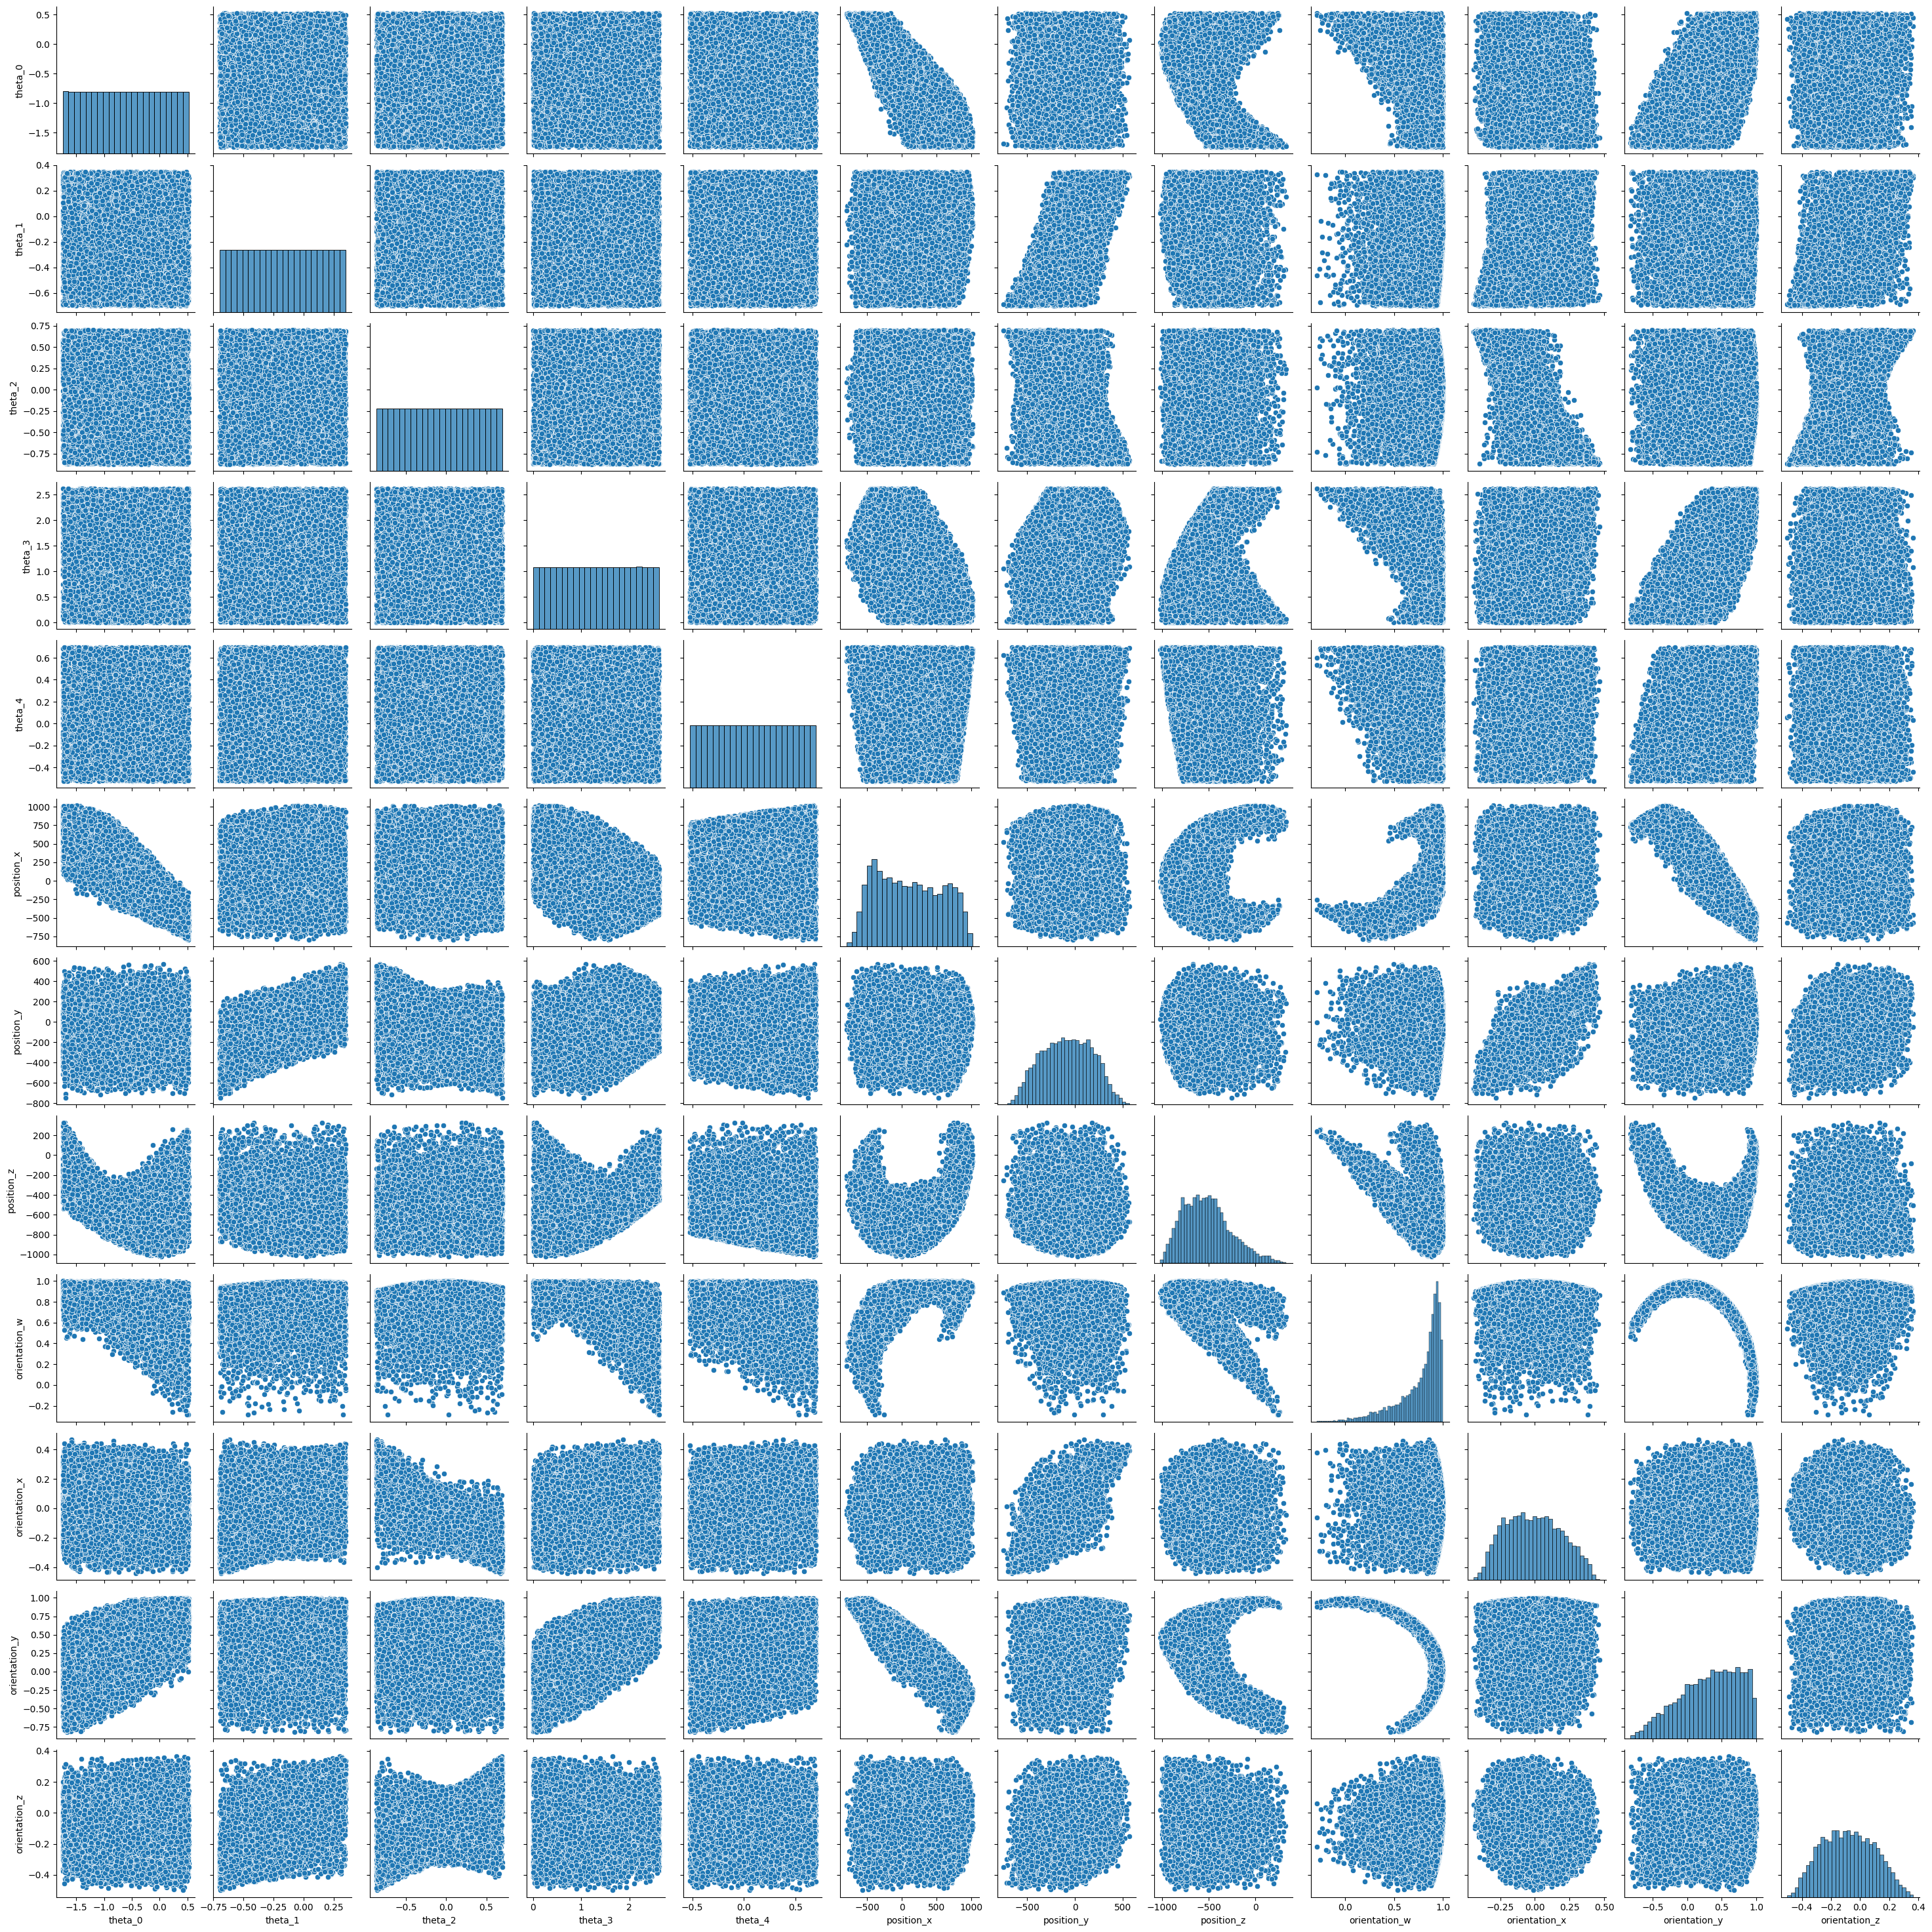

In [15]:
sns.pairplot(data)

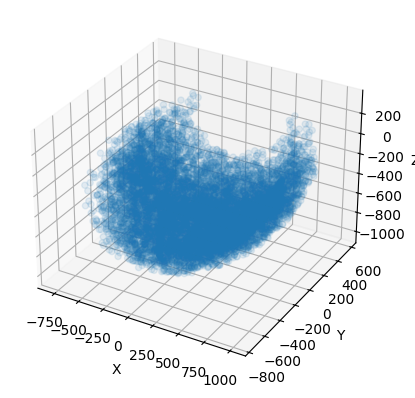

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['position_x'], data['position_y'], data['position_z'], alpha=0.1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [17]:
X = data.drop(target_symbols, axis=1)
y = data.drop(feature_symbols, axis=1)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
class polynomial_transformer:
  def __init__(self, degree=2, include_bias=True):
    self.degree = degree
    self.include_bias = include_bias

  @staticmethod
  @partial(jit, static_argnums=[1, 2])
  def __expand(Xp, include_bias, degree):
      n_samples, n_features = X.shape
      combinations = []
      for deg in range(1, degree + 1):
        combinations.extend(itertools.combinations_with_replacement(range(n_features), deg))

      n_samples, n_features = Xp.shape
      n_output_features = len(combinations)
      X_new = jnp.empty((n_samples, n_output_features), dtype=jnp.float64)
      for i, index_combi in enumerate(combinations):
        X_new = X_new.at[:, i].set(jnp.prod(Xp[:, index_combi], axis=1, dtype=jnp.float64))

      if include_bias:
        X_new = jnp.c_[jnp.ones(n_samples), X_new]
      return X_new

  def transform(self, X, y=None):
    X_new = self.__expand(X, self.include_bias, self.degree)
    return X_new


class Standard_Scaler:
    def __init__(self):
        self.mean = None
        self.std = None

    @staticmethod
    @jit
    def __j_fit(X):
      mean = jnp.mean(X, axis=0)
      std = jnp.std(X, axis=0)
      return mean, std

    def fit(self, X):
      self.mean, self.std = self.__j_fit(X)
      return self

    @staticmethod
    @jit
    def __j_transform(X, mean, std):
      X_scaled = (X - mean) / std
      return X_scaled

    def transform(self, X):
        X_scaled = self.__j_transform(X, self.mean, self.std)
        return X_scaled

    def inverse_transform(self, X_scaled):
        X = (X_scaled * self.std) + self.mean
        return X


class linear_regressor:
  def __init__(self, fit_intercept=True):
    self.weights = None
    self.bias = None
    self.fit_intercept = fit_intercept

  @staticmethod
  @partial(jit, static_argnums=[2])
  def __j_fit(X, y, fit_intercept):

      X_mean = jnp.mean(X, axis=0)

      y_mean = jnp.mean(y, axis=0)

      if fit_intercept:
        X_centered = X - X_mean
        y_centered = y - y_mean
        weights = jnp.linalg.lstsq(X_centered, y_centered)[0]
      else:
        weights = jnp.linalg.lstsq(X, y)[0]


      bias = y_mean - jnp.dot(X_mean, weights)
      return weights, bias

  def fit(self, X, y):
    self.weights, self.bias = self.__j_fit(X, y, self.fit_intercept)
    return self



  def predict(self, X):
    return jnp.dot(X, self.weights) + self.bias


In [20]:
X_train_jnp = jnp.array(X_train.values, dtype=np.float64)
y_train_jnp = jnp.array(y_train.values, dtype=np.float64)

X_test_jnp = jnp.array(X_test.values, dtype=np.float64)
y_test_jnp = jnp.array(y_test.values, dtype=np.float64)

scaler = Standard_Scaler()
scaler.fit(X.values)
X_train_jnp = scaler.transform(X_train_jnp)
X_test_jnp = scaler.transform(X_test_jnp)

poly = polynomial_transformer(degree=5, include_bias=True)
X_train_poly = poly.transform(X_train_jnp)

lr = linear_regressor(fit_intercept=True)
lr.fit(X_train_poly, y_train_jnp)

y_train_pred = lr.predict(X_train_poly)

X_test_poly = poly.transform(X_test_jnp)
y_pred = lr.predict(X_test_poly)

print(f'Training set score: {r2_score(y_train_jnp, y_train_pred):.3f}')
print(f'Test set score: {r2_score(y_test, y_pred):.3f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.3f}')

Training set score: 0.999
Test set score: 0.998
MSE: 0.000
MAE: 0.013


In [21]:
def cross_val_score_jax(model, X, y, k=5, random_state=None):

  key = random.PRNGKey(random_state) if random_state else random.PRNGKey(0)
  scores = []
  all_preds = []
  n_samples = len(X)


  shuffled_indices = random.permutation(key, jnp.arange(n_samples))
  fold_size = n_samples // k
  folds = [shuffled_indices[i * fold_size:(i + 1) * fold_size] for i in range(k)]

  for i in range(k):
    test_index = folds[i]
    train_index = jnp.concatenate([fold for j, fold in enumerate(folds) if j != i])

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)
    scores.append(score)

  scores = jnp.array(scores)
  mean_score = jnp.mean(scores)
  std_score = jnp.std(scores)

  return scores, mean_score, std_score


In [22]:
lr_cv = linear_regressor(fit_intercept=True)
X_jnp = jnp.array(X.values, dtype=np.float64)
y_jnp = jnp.array(y.values, dtype=np.float64)
X_jnp = scaler.transform(X_jnp)
X_jnp = poly.transform(X_jnp)
scores, mean_score, std_score = cross_val_score_jax(lr_cv, X_jnp, y_jnp, k=5, random_state=42)
print(f'Scores: {scores}')
print(f'Mean score: {mean_score:.3f}')
print(f'Std score: {std_score:.3f}')

Scores: [0.99824015 0.99848701 0.99847962 0.99852945 0.99840721]
Mean score: 0.998
Std score: 0.000
